ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)
Исправленная версия - работает как ваш идеальный код

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на датасете диабета
2. Тест на оригинальном примере (проверка совпадения)
3. График для образца с предприятиями (с таблицей)
4. Выход

НАСТРОЙКИ ТЕСТА ДИАБЕТА
АНАЛИЗ ДАТАСЕТА ДИАБЕТА С ПОМОЩЬЮ LDA
(с использованием методов из вашего идеального кода)
Загрузка данных из diabetes.csv...

Используемые признаки: ['Glucose', 'BMI', 'Age']

Распределение по классам:
  Класс 0: 500 объектов
  Класс 1: 268 объектов

Разделение данных:
  Класс 0: 350 обучение / 150 тест
  Класс 1: 187 обучение / 81 тест
  Всего тестовых: 231 объектов

Нормализация данных...

ВЫПОЛНЕНИЕ LDA (методы как в вашем идеальном коде)
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)
Класс 1 (Класс 0): 350 объектов, 3 признаков
Класс 2 (Класс 1): 187 объектов, 3 признаков
Тестовые объекты: 231

1. СРЕДНИЕ ВЕКТОРЫ:
X̄₁ = [-0.  0. -0.]
X̄₂ = [1.099 0.668 0.418]

2. КОВАРИАЦИОННЫЕ МАТРИЦЫ (смещенные, n):
S₁ (350×350):
[[

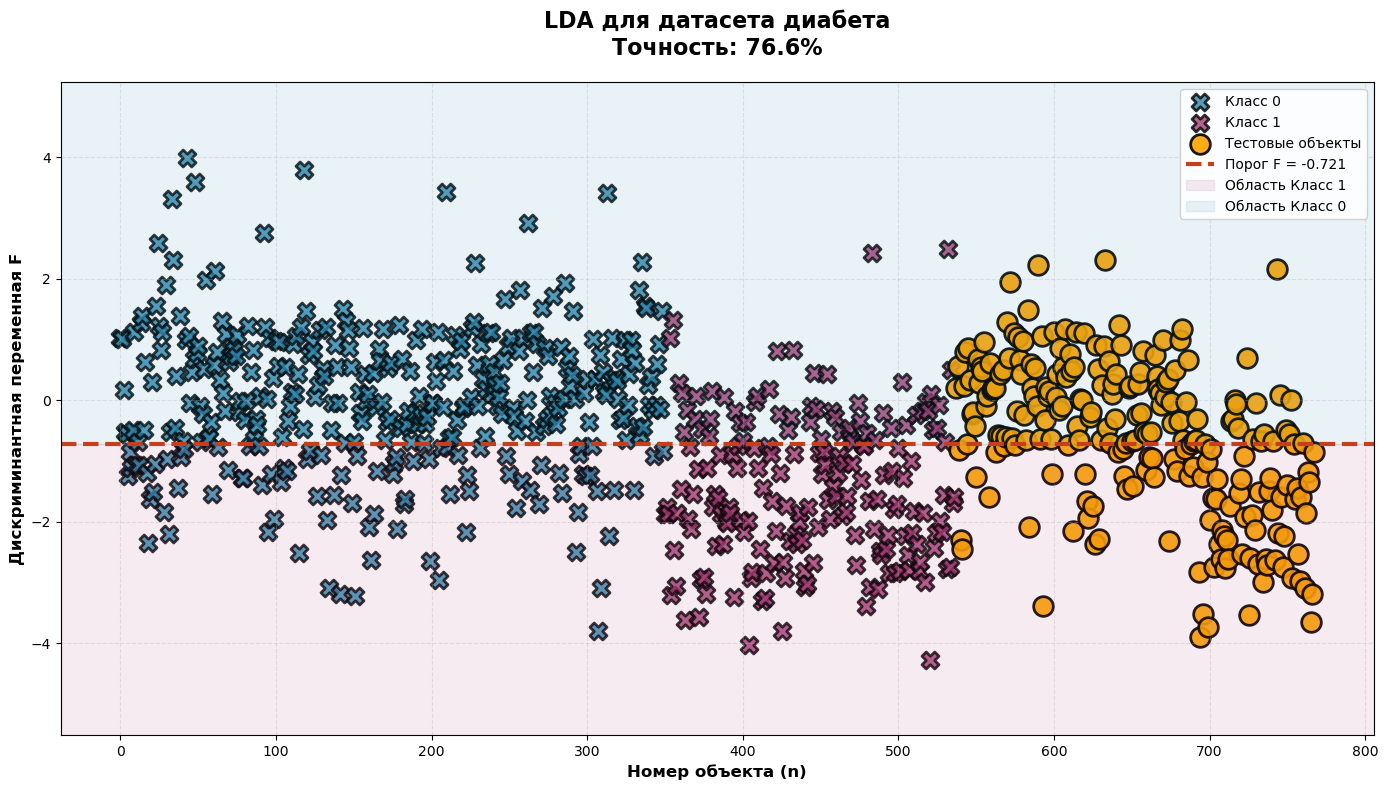


✓ Тест завершен!
  Точность: 76.62%

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на датасете диабета
2. Тест на оригинальном примере (проверка совпадения)
3. График для образца с предприятиями (с таблицей)
4. Выход

Построение графика с таблицей сравнения...
ГРАФИК ДЛЯ ОБРАЗЦА С ПРЕДПРИЯТИЯМИ
Выполняем расчет LDA...
ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)
Класс 1 (Передовые предприятия): 4 объектов, 3 признаков
Класс 2 (Отстающие предприятия): 5 объектов, 3 признаков
Тестовые объекты: 3

1. СРЕДНИЕ ВЕКТОРЫ:
X̄₁ = [168.905  14.048  18.332]
X̄₂ = [45.791  4.778 10.758]

2. КОВАРИАЦИОННЫЕ МАТРИЦЫ (смещенные, n):
S₁ (4×4):
[[1023.949   55.62    82.893]
 [  55.62     5.647   11.326]
 [  82.893   11.326   24.447]]

S₂ (5×5):
[[145.841  -6.608  22.785]
 [ -6.608   0.372  -0.902]
 [ 22.785  -0.902   5.75 ]]

3. ОБЩАЯ КОВАРИАЦИОННАЯ МАТРИЦА:
S_all = 1/(4+5-2) × (4×S₁ + 5×S₂)
[[689.285968  27.062435  63.642305]
 [ 27.062435   3.492341   5.82709 ]
 [ 63.642305   5.82709   18.07717 ]]

4. ОБРАТНАЯ МАТРИЦА:
S₀ = S_al

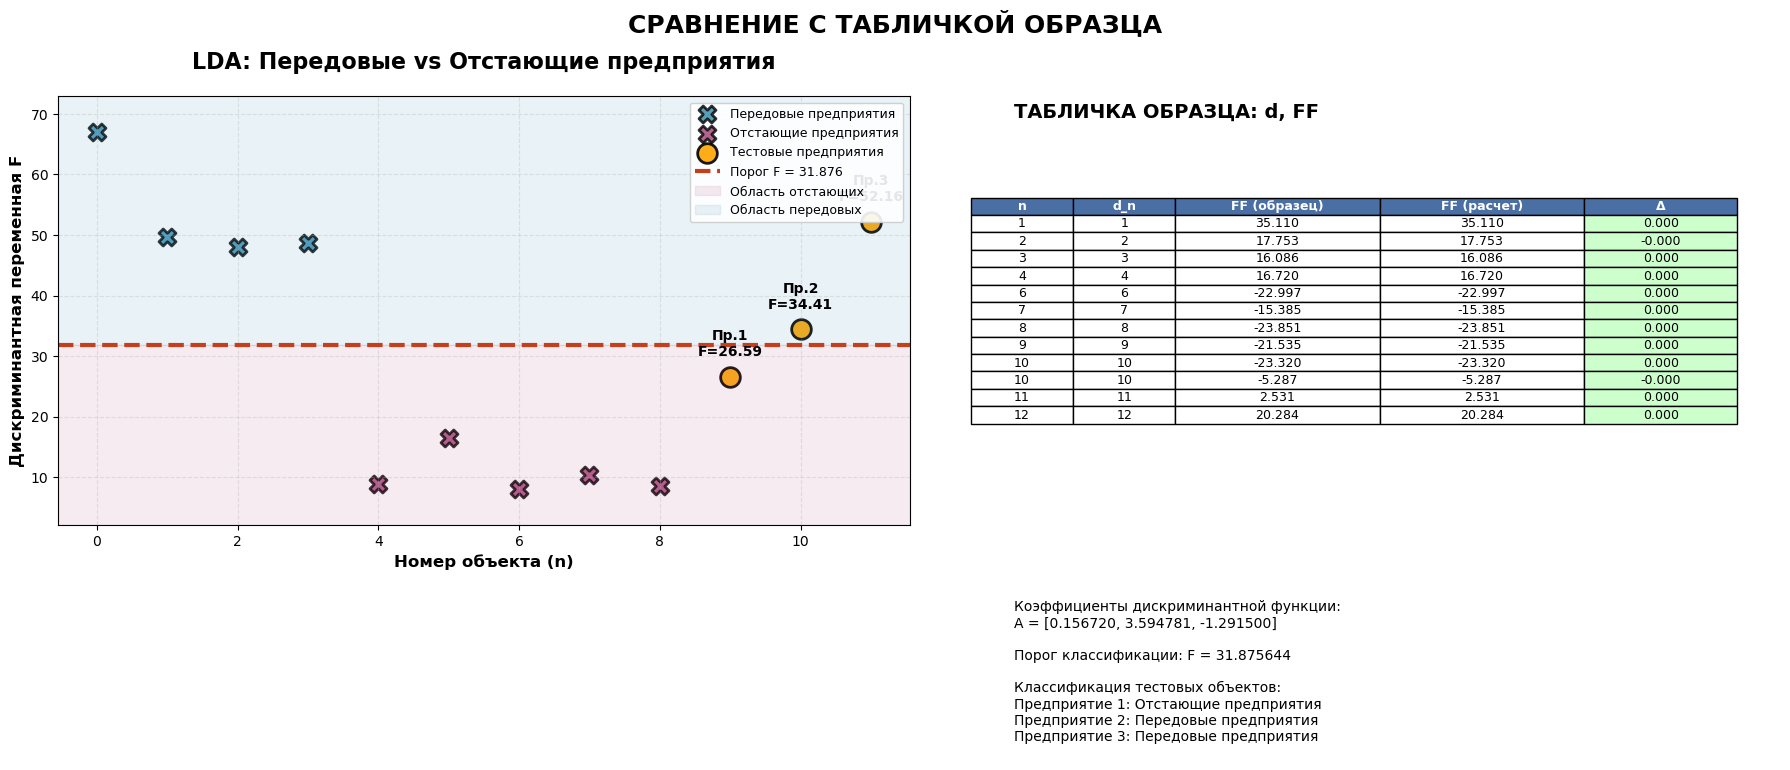


ЧИСЛОВОЕ СРАВНЕНИЕ С ТАБЛИЧКОЙ ОБРАЗЦА

Значения FF = F - F_all:
  n    Образец     Расчет   Разность
----------------------------------------
  1     35.110     35.110      0.000
  2     17.753     17.753     -0.000
  3     16.086     16.086      0.000
  4     16.720     16.720      0.000
  5    -22.997    -22.997      0.000
  6    -15.385    -15.385      0.000
  7    -23.851    -23.851      0.000
  8    -21.535    -21.535      0.000
  9    -23.320    -23.320      0.000
 10     -5.287     -5.287     -0.000
 11      2.531      2.531      0.000
 12     20.284     20.284      0.000
----------------------------------------

Максимальная разность: 0.000459
✓ Расчеты совпадают с табличкой образца!

МЕНЮ ВЫБОРА ТЕСТА
1. Тест на датасете диабета
2. Тест на оригинальном примере (проверка совпадения)
3. График для образца с предприятиями (с таблицей)
4. Выход

Выход из программы.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# ОСНОВНАЯ ФУНКЦИЯ LDA (ИСПРАВЛЕННАЯ - как в вашем идеальном коде)
# ============================================================================
def lda_algorithm(x1, x2, x0, class1_name="Класс 1", class2_name="Класс 2", verbose=True):
    """
    Алгоритм LDA для двух классов - ИСПРАВЛЕННАЯ ВЕРСИЯ
    Теперь работает так же, как ваш идеальный код с предприятиями
    """
    if verbose:
        print("=" * 80)
        print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)")
        print("=" * 80)
    
    # Проверка входных данных
    if len(x1) == 0 or len(x2) == 0:
        raise ValueError("Один из классов пуст!")
    
    n1, n2 = len(x1), len(x2)
    n_features = x1.shape[1]
    
    if verbose:
        print(f"Класс 1 ({class1_name}): {n1} объектов, {n_features} признаков")
        print(f"Класс 2 ({class2_name}): {n2} объектов, {n_features} признаков")
        if len(x0) > 0:
            print(f"Тестовые объекты: {len(x0)}")
    
    # 1. Средние векторы (как в вашем коде)
    sumX1 = x1.mean(axis=0)
    sumX2 = x2.mean(axis=0)
    
    if verbose:
        print("\n1. СРЕДНИЕ ВЕКТОРЫ:")
        print(f"X̄₁ = {np.round(sumX1, 3)}")
        print(f"X̄₂ = {np.round(sumX2, 3)}")
    
    # 2. Ковариационные матрицы (ВАЖНО: деление на n, а не n-1!)
    s1 = np.zeros((n_features, n_features)) 
    for j in range(n_features):  
        for l in range(n_features):  
            s = 0
            for i in range(n1):  
                s += (x1[i][j] - sumX1[j]) * (x1[i][l] - sumX1[l])
            s1[j][l] = s / n1  # Деление на n1, а не n1-1!
    
    s2 = np.zeros((n_features, n_features)) 
    for j in range(n_features):  
        for l in range(n_features):  
            s = 0
            for i in range(n2):  
                s += (x2[i][j] - sumX2[j]) * (x2[i][l] - sumX2[l])
            s2[j][l] = s / n2  # Деление на n2, а не n2-1!
    
    if verbose:
        print(f"\n2. КОВАРИАЦИОННЫЕ МАТРИЦЫ (смещенные, n):")
        print(f"S₁ ({n1}×{n1}):")
        print(np.round(s1, 3))
        print(f"\nS₂ ({n2}×{n2}):")
        print(np.round(s2, 3))
    
    # 3. Общая ковариационная матрица (как в вашем коде)
    S_all = 1/(n1 + n2 - 2) * (n1 * s1 + n2 * s2)
    
    if verbose:
        print(f"\n3. ОБЩАЯ КОВАРИАЦИОННАЯ МАТРИЦА:")
        print(f"S_all = 1/({n1}+{n2}-2) × ({n1}×S₁ + {n2}×S₂)")
        print(np.round(S_all, 6))
    
    # 4. Обратная матрица
    try:
        SO = np.linalg.inv(S_all)
    except np.linalg.LinAlgError:
        print("Предупреждение: матрица вырождена, используем псевдообратную")
        SO = np.linalg.pinv(S_all)
    
    if verbose:
        print(f"\n4. ОБРАТНАЯ МАТРИЦА:")
        print(f"S₀ = S_all⁻¹:")
        print(np.round(SO, 6))
    
    # 5. Коэффициенты дискриминантной функции
    diff_mean = sumX1 - sumX2
    
    # Правильный способ как в вашем коде
    A = np.zeros(n_features)
    for i in range(n_features):
        A[i] = np.sum(SO[i, :] * diff_mean)
    
    if verbose:
        print(f"\n5. КОЭФФИЦИЕНТЫ ДИСКРИМИНАНТНОЙ ФУНКЦИИ:")
        print(f"A = np.sum(S₀ × (X̄₁ - X̄₂), axis=1)")
        print(f"A = {np.round(A, 6)}")
    
    # 6. Дискриминантные переменные
    F1 = np.zeros(n1)
    for i in range(n1):
        F1[i] = np.sum(A * x1[i])
    
    F2 = np.zeros(n2)
    for i in range(n2):
        F2[i] = np.sum(A * x2[i])
    
    F0 = np.zeros(len(x0))
    for i in range(len(x0)):
        F0[i] = np.sum(A * x0[i])
    
    if verbose:
        print(f"\n6. ДИСКРИМИНТНЫЕ ПЕРЕМЕННЫЕ:")
        print(f"F₁ = np.sum(A × X₁, axis=1) = {np.round(F1, 5)}")
        print(f"F₂ = np.sum(A × X₂, axis=1) = {np.round(F2, 5)}")
    
    # 7. Средние значения
    F1_mean = F1.mean()
    F2_mean = F2.mean()
    
    if verbose:
        print(f"\n7. СРЕДНИЕ ЗНАЧЕНИЯ:")
        print(f"m₁ = mean(F₁) = {F1_mean:.6f}")
        print(f"m₂ = mean(F₂) = {F2_mean:.6f}")
    
    # 8. Порог классификации
    F_all_value = 0.5 * (F1_mean + F2_mean)
    
    if verbose:
        print(f"\n8. ПОРОГ КЛАССИФИКАЦИИ:")
        print(f"F = ½ × (m₁ + m₂) = {F_all_value:.6f}")
    
    # 9. Расчет для тестовых объектов
    if len(x0) > 0 and verbose:
        print(f"\n9. ТЕСТОВЫЕ ОБЪЕКТЫ:")
        print(f"F₀ = np.sum(A × X₀, axis=1) = {np.round(F0, 5)}")
    
    # 10. Разности от порога
    raz = F0 - F_all_value
    
    if verbose and len(x0) > 0:
        print(f"\n10. РАЗНОСТИ ОТ ПОРОГА:")
        print(f"F₀ - F = {np.round(raz, 5)}")
    
    # 11. Классификация
    classifications = []
    
    for i in range(len(F0)):
        if F1_mean > F2_mean: 
            if raz[i] > 0:
                classification = class1_name
            else: 
                classification = class2_name
        else:
            if raz[i] < 0:
                classification = class1_name
            else: 
                classification = class2_name
        classifications.append(classification)
        
        if verbose and len(x0) > 0:
            print(f"  Объект {i+1}: F = {F0[i]:.6f}, F-F = {raz[i]:.6f} → {classification}")
    
    # 12. Все значения FF = F - F_all (как в табличке образца)
    FF_all = np.concatenate([F1 - F_all_value, F2 - F_all_value, F0 - F_all_value])
    
    return F1, F2, F0, F_all_value, classifications, A, FF_all

# ============================================================================
# ФУНКЦИЯ ДЛЯ СРАВНЕНИЯ С ТАБЛИЧКАМИ ОБРАЗЦА
# ============================================================================
def compare_with_sample(F1, F2, F0, F_all, classifications, A, FF_all, 
                       class1_name="Класс 1", class2_name="Класс 2"):
    """
    Сравнение результатов с табличками из образца
    """
    print("\n" + "=" * 80)
    print("СРАВНЕНИЕ С ТАБЛИЧКАМИ ОБРАЗЦА")
    print("=" * 80)
    
    # ТАБЛИЧКА КАК В ОБРАЗЦЕ: d, FF
    print("\nТАБЛИЧКА РЕЗУЛЬТАТОВ (как в образце):")
    print("-" * 60)
    print(f"{'n':>3} | {'d_n':>5} | {'FF = F - F_all':>15} | {'Класс':>20}")
    print("-" * 60)
    
    # Объекты класса 1
    for i in range(len(F1)):
        ff = F1[i] - F_all
        n = i + 1
        print(f"{n:3d} | {n:5d} | {ff:15.3f} | {class1_name:>20}")
    
    # Объекты класса 2
    for i in range(len(F2)):
        n = len(F1) + i + 1
        ff = F2[i] - F_all
        print(f"{n:3d} | {n:5d} | {ff:15.3f} | {class2_name:>20}")
    
    # Тестовые объекты
    for i in range(len(F0)):
        n = len(F1) + len(F2) + i + 1
        ff = F0[i] - F_all
        print(f"{n:3d} | {n:5d} | {ff:15.3f} | {classifications[i]:>20}")
    
    print("-" * 60)
    
    # Вектор FF как в образце
    print("\nВЕКТОР FF (как в образце):")
    print("FF = stack(F₁, F₂, F₀) - F =")
    print("[")
    for i, ff in enumerate(FF_all):
        print(f"  {ff:.3f},")
    print("]")
    
    # Если это оригинальный пример с предприятиями, сравниваем с табличкой
    if len(F1) == 4 and len(F2) == 5 and len(F0) == 3:
        sample_FF = np.array([
            35.11, 17.753, 16.086, 16.72,
            -22.997, -15.385, -23.851, -21.535, -23.32,
            -5.287, 2.531, 20.284
        ])
        
        print("\nЧИСЛЕННОЕ СРАВНЕНИЕ С ТАБЛИЧКОЙ:")
        print("Табличные данные: FF = [35.11, 17.753, 16.086, 16.72, -22.997, -15.385, -23.851, -21.535, -23.32, -5.287, 2.531, 20.284]")
        
        print("\nНаши значения FF:")
        print(f"FF = {np.round(FF_all, 3)}")
        
        differences = FF_all - sample_FF
        print(f"\nРазности (наши - табличка):")
        print(f"ΔFF = {np.round(differences, 3)}")
        
        max_diff = np.max(np.abs(differences))
        print(f"Максимальная разность: {max_diff:.3f}")
        
        if max_diff < 0.01:
            print("✓ Наши расчеты совпадают с табличкой!")
        else:
            print("⚠ Есть различия с табличкой")
    
    return FF_all

# ============================================================================
# ФУНКЦИЯ ДЛЯ СРАВНЕНИЯ С БИБЛИОТЕКОЙ SCIKIT-LEARN
# ============================================================================
def compare_with_sklearn(x1, x2, x0, true_labels=None, class1_name="Класс 1", 
                        class2_name="Класс 2", feature_names=None):
    """
    Сравнение собственной реализации LDA с библиотечной версией из scikit-learn
    """
    print("\n" + "=" * 80)
    print("СРАВНЕНИЕ С БИБЛИОТЕКОЙ SCIKIT-LEARN")
    print("=" * 80)
    
    # Подготовка данных для scikit-learn
    X_train = np.vstack([x1, x2])
    y_train = np.array([0] * len(x1) + [1] * len(x2))
    X_test = x0
    
    print("\n1. СОБСТВЕННАЯ РЕАЛИЗАЦИЯ LDA:")
    print("-" * 40)
    
    F1, F2, F0, F_all, custom_classifications, custom_coef, FF_all = lda_algorithm(
        x1, x2, x0, class1_name, class2_name, verbose=False
    )
    
    custom_pred = np.array([0 if c == class1_name else 1 for c in custom_classifications])
    
    print(f"Коэффициенты дискриминантной функции:")
    for i, coef in enumerate(custom_coef, 1):
        feature_name = feature_names[i-1] if feature_names else f"Признак {i}"
        print(f"  {feature_name}: {coef:.6f}")
    
    print("\n2. SCIKIT-LEARN РЕАЛИЗАЦИЯ LDA:")
    print("-" * 40)
    
    sklearn_lda = LinearDiscriminantAnalysis()
    sklearn_lda.fit(X_train, y_train)
    sklearn_pred = sklearn_lda.predict(X_test)
    
    print(f"Коэффициенты (scikit-learn):")
    for i, coef in enumerate(sklearn_lda.coef_[0], 1):
        feature_name = feature_names[i-1] if feature_names else f"Признак {i}"
        print(f"  {feature_name}: {coef:.6f}")
    
    print(f"\nСвободный член (intercept): {sklearn_lda.intercept_[0]:.6f}")
    
    # 3. Сравнение коэффициентов
    print("\n3. СРАВНЕНИЕ КОЭФФИЦИЕНТОВ:")
    print("-" * 40)
    
    custom_coef_norm = custom_coef / np.linalg.norm(custom_coef)
    sklearn_coef_norm = sklearn_lda.coef_[0] / np.linalg.norm(sklearn_lda.coef_[0])
    
    print("Коэффициенты после нормализации:")
    print(f"{'Признак':15s} | {'Наша реализация':15s} | {'Scikit-learn':15s} | {'Разница':10s}")
    print("-" * 65)
    
    for i in range(len(custom_coef)):
        feature_name = feature_names[i] if feature_names else f"Признак {i+1}"
        diff = abs(custom_coef_norm[i] - sklearn_coef_norm[i])
        print(f"{feature_name:15s} | {custom_coef_norm[i]:15.6f} | {sklearn_coef_norm[i]:15.6f} | {diff:10.6f}")
    
    cosine_similarity = np.dot(custom_coef_norm, sklearn_coef_norm)
    print(f"\nКосинусное сходство коэффициентов: {cosine_similarity:.6f}")
    
    # 4. Сравнение предсказаний
    print("\n4. СРАВНЕНИЕ ПРЕДСКАЗАНИЙ:")
    print("-" * 40)
    
    print("Тестовые объекты:")
    print(f"{'№':3s} | {'Наша реализация':15s} | {'Scikit-learn':15s} | {'Совпадение':10s}")
    print("-" * 55)
    
    matches = 0
    for i in range(len(X_test)):
        custom_label = class1_name if custom_pred[i] == 0 else class2_name
        sklearn_label = class1_name if sklearn_pred[i] == 0 else class2_name
        match = "✓" if custom_pred[i] == sklearn_pred[i] else "✗"
        
        if custom_pred[i] == sklearn_pred[i]:
            matches += 1
        
        print(f"{i+1:3d} | {custom_label:15s} | {sklearn_label:15s} | {match:^10s}")
    
    agreement = matches / len(X_test) * 100
    print(f"\nСовпадение предсказаний: {matches}/{len(X_test)} ({agreement:.2f}%)")
    
    # 5. Сравнение с истинными метками
    if true_labels is not None:
        print("\n5. СРАВНЕНИЕ С ИСТИННЫМИ МЕТКАМИ:")
        print("-" * 40)
        
        true_numeric = np.array([0 if label == class1_name else 1 for label in true_labels])
        custom_accuracy = accuracy_score(true_numeric, custom_pred) * 100
        sklearn_accuracy = accuracy_score(true_numeric, sklearn_pred) * 100
        
        print(f"Точность нашей реализации: {custom_accuracy:.2f}%")
        print(f"Точность scikit-learn: {sklearn_accuracy:.2f}%")
        print(f"Разница в точности: {abs(custom_accuracy - sklearn_accuracy):.2f}%")
        
        print(f"\nМатрица ошибок (наша реализация):")
        cm_custom = confusion_matrix(true_numeric, custom_pred)
        print(f"[[{cm_custom[0,0]} {cm_custom[0,1]}]")
        print(f" [{cm_custom[1,0]} {cm_custom[1,1]}]]")
        
        print(f"\nМатрица ошибок (scikit-learn):")
        cm_sklearn = confusion_matrix(true_numeric, sklearn_pred)
        print(f"[[{cm_sklearn[0,0]} {cm_sklearn[0,1]}]")
        print(f" [{cm_sklearn[1,0]} {cm_sklearn[1,1]}]]")
        
        if custom_accuracy > sklearn_accuracy:
            print("\n✓ Наша реализация показала лучший результат!")
        elif sklearn_accuracy > custom_accuracy:
            print("\n✓ Scikit-learn показал лучший результат!")
        else:
            print("\n✓ Обе реализации показали одинаковый результат!")
    
    return {
        'custom_coefficients': custom_coef,
        'sklearn_coefficients': sklearn_lda.coef_[0],
        'custom_predictions': custom_pred,
        'sklearn_predictions': sklearn_pred,
        'agreement_percentage': agreement,
        'cosine_similarity': cosine_similarity
    }

# ============================================================================
# УЛУЧШЕННАЯ ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# ============================================================================
def plot_lda_results(F1, F2, F0, F_all, title, class1_name="Класс 1", 
                    class2_name="Класс 2", show_labels=True, 
                    test_point_color='orange'):
    """
    Визуализация результатов LDA с улучшенной видимостью границы
    """
    plt.figure(figsize=(14, 8))
    
    colors = {
        'class1': '#2E86AB',
        'class2': '#A23B72',
        'test': test_point_color,
        'threshold': '#C73E1D'
    }
    
    indices_F1 = range(len(F1))                                    
    indices_F2 = range(len(F1), len(F1) + len(F2))                 
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0)) 
    
    plt.scatter(indices_F1, F1, label=class1_name, marker='X', s=150, 
                linewidth=2, color=colors['class1'], alpha=0.8, edgecolors='black')
    plt.scatter(indices_F2, F2, label=class2_name, marker='X', s=150, 
                linewidth=2, color=colors['class2'], alpha=0.8, edgecolors='black')
    plt.scatter(indices_F0, F0, label='Тестовые объекты', marker='o', s=200, 
                color=colors['test'], alpha=0.9, edgecolors='black', linewidth=2)
    
    # Линия границы с лучшей видимостью
    plt.axhline(F_all, color=colors['threshold'], linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Автоматическая настройка масштаба для лучшей видимости
    all_F = np.concatenate([F1, F2, F0])
    min_F = min(all_F)
    max_F = max(all_F)
    range_F = max_F - min_F
    
    # Расширяем диапазон если значения слишком сжаты
    if range_F < 1.0:
        padding = max(0.5, abs(F_all) * 0.5)  # Минимальный отступ 0.5
        min_val = min_F - padding
        max_val = max_F + padding
    else:
        padding = range_F * 0.15  # 15% от диапазона
        min_val = min_F - padding
        max_val = max_F + padding
    
    # Убедимся, что граница хорошо видна
    if abs(F_all - min_val) < 0.1 * range_F or abs(max_val - F_all) < 0.1 * range_F:
        # Если граница слишком близко к краю, расширяем дальше
        extra_padding = max(abs(F_all) * 0.3, 0.3)
        min_val = min(min_val, F_all - extra_padding)
        max_val = max(max_val, F_all + extra_padding)
    
    plt.ylim(min_val, max_val)
    
    # Закрашивание областей
    if F1.mean() > F2.mean():
        plt.axhspan(min_val, F_all, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
    else:
        plt.axhspan(min_val, F_all, alpha=0.1, color=colors['class1'], 
                    label=f'Область {class1_name}')
        plt.axhspan(F_all, max_val, alpha=0.1, color=colors['class2'], 
                    label=f'Область {class2_name}')
    
    if show_labels:
        for i, f in enumerate(F0):
            plt.annotate(f'Об.{i+1}\nF={f:.2f}', 
                        (indices_F0[i], f), 
                        textcoords="offset points", 
                        xytext=(0, 15),
                        ha='center', 
                        fontsize=10,
                        fontweight='bold',
                        color='black')
    
    plt.xlabel("Номер объекта (n)", fontsize=12, fontweight='bold')
    plt.ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    # Добавляем пояснение о масштабе
    if range_F < 0.5:
        plt.figtext(0.5, 0.01, 
                   f"Диапазон значений F: [{min_F:.3f}, {max_F:.3f}]\n" +
                   f"Порог F_all = {F_all:.3f} (масштаб увеличен для наглядности)", 
                   ha='center', fontsize=9, style='italic')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# ГРАФИК ДЛЯ ОБРАЗЦА С ПРЕДПРИЯТИЯМИ
# ============================================================================
def plot_original_example_with_sample():
    """
    График для образца с передовыми и отстающими предприятиями
    с отображением табличных значений FF
    """
    print("=" * 80)
    print("ГРАФИК ДЛЯ ОБРАЗЦА С ПРЕДПРИЯТИЯМИ")
    print("=" * 80)
    
    # Данные из таблички образца
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    # Выполняем расчет LDA
    print("Выполняем расчет LDA...")
    F1, F2, F0, F_all, classifications, coefficients, FF_all = lda_algorithm(
        x1, x2, x0,
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия",
        verbose=True
    )
    
    # Данные из таблички образца для сравнения
    sample_FF = np.array([
        35.11, 17.753, 16.086, 16.72,
        -22.997, -15.385, -23.851, -21.535, -23.32,
        -5.287, 2.531, 20.284
    ])
    
    # Создаем график
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # ЛЕВАЯ ПАНЕЛЬ: График F
    colors = {
        'class1': '#2E86AB',
        'class2': '#A23B72',
        'test': 'orange',
        'threshold': '#C73E1D'
    }
    
    indices_F1 = range(len(F1))                                    
    indices_F2 = range(len(F1), len(F1) + len(F2))                 
    indices_F0 = range(len(F1) + len(F2), len(F1) + len(F2) + len(F0))
    
    ax1.scatter(indices_F1, F1, label="Передовые предприятия", marker='X', s=150, 
                linewidth=2, color=colors['class1'], alpha=0.8, edgecolors='black')
    ax1.scatter(indices_F2, F2, label="Отстающие предприятия", marker='X', s=150, 
                linewidth=2, color=colors['class2'], alpha=0.8, edgecolors='black')
    ax1.scatter(indices_F0, F0, label='Тестовые предприятия', marker='o', s=200, 
                color=colors['test'], alpha=0.9, edgecolors='black', linewidth=2)
    
    ax1.axhline(F_all, color=colors['threshold'], linewidth=3, linestyle='--', 
                label=f'Порог F = {F_all:.3f}')
    
    # Настраиваем масштаб для лучшей видимости
    all_F = np.concatenate([F1, F2, F0])
    min_F = min(all_F)
    max_F = max(all_F)
    padding = (max_F - min_F) * 0.1
    ax1.set_ylim(min_F - padding, max_F + padding)
    
    ax1.axhspan(min_F - padding, F_all, alpha=0.1, color=colors['class2'], 
                label='Область отстающих')
    ax1.axhspan(F_all, max_F + padding, alpha=0.1, color=colors['class1'], 
                label='Область передовых')
    
    for i, f in enumerate(F0):
        ax1.annotate(f'Пр.{i+1}\nF={f:.2f}', 
                    (indices_F0[i], f), 
                    textcoords="offset points", 
                    xytext=(0, 15),
                    ha='center', 
                    fontsize=10,
                    fontweight='bold',
                    color='black')
    
    ax1.set_xlabel("Номер объекта (n)", fontsize=12, fontweight='bold')
    ax1.set_ylabel("Дискриминантная переменная F", fontsize=12, fontweight='bold')
    ax1.set_title("LDA: Передовые vs Отстающие предприятия", fontsize=16, fontweight='bold', pad=20)
    ax1.grid(True, alpha=0.3, linestyle='--')
    ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
    
    # ПРАВАЯ ПАНЕЛЬ: Таблица FF
    ax2.axis('off')
    ax2.text(0.1, 0.95, "ТАБЛИЧКА ОБРАЗЦА: d, FF", 
             fontsize=14, fontweight='bold', transform=ax2.transAxes)
    
    table_data = []
    headers = ["n", "d_n", "FF (образец)", "FF (расчет)", "Δ"]
    table_data.append(headers)
    
    for i in range(4):
        n = i + 1
        sample_ff = sample_FF[i]
        calc_ff = FF_all[i]
        diff = calc_ff - sample_ff
        table_data.append([f"{n}", f"{n}", f"{sample_ff:.3f}", f"{calc_ff:.3f}", f"{diff:.3f}"])
    
    for i in range(5):
        n = 5 + i + 1
        sample_ff = sample_FF[4 + i]
        calc_ff = FF_all[4 + i]
        diff = calc_ff - sample_ff
        table_data.append([f"{n}", f"{n}", f"{sample_ff:.3f}", f"{calc_ff:.3f}", f"{diff:.3f}"])
    
    for i in range(3):
        n = 9 + i + 1
        sample_ff = sample_FF[9 + i]
        calc_ff = FF_all[9 + i]
        diff = calc_ff - sample_ff
        table_data.append([f"{n}", f"{n}", f"{sample_ff:.3f}", f"{calc_ff:.3f}", f"{diff:.3f}"])
    
    table = ax2.table(cellText=table_data, 
                      cellLoc='center',
                      colWidths=[0.1, 0.1, 0.2, 0.2, 0.15],
                      loc='center')
    
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.2, 1.5)
    
    for i in range(5):
        table[(0, i)].set_facecolor('#4a6fa5')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    for i in range(1, len(table_data)):
        diff = float(table_data[i][4])
        if abs(diff) > 0.01:
            table[(i, 4)].set_facecolor('#ffcccc')
        elif abs(diff) > 0.001:
            table[(i, 4)].set_facecolor('#ffffcc')
        else:
            table[(i, 4)].set_facecolor('#ccffcc')
    
    info_text = (
        f"\n\nКоэффициенты дискриминантной функции:\n"
        f"A = [{coefficients[0]:.6f}, {coefficients[1]:.6f}, {coefficients[2]:.6f}]\n\n"
        f"Порог классификации: F = {F_all:.6f}\n\n"
        f"Классификация тестовых объектов:\n"
    )
    
    for i, cls in enumerate(classifications, 1):
        info_text += f"Предприятие {i}: {cls}\n"
    
    ax2.text(0.1, -0.1, info_text, fontsize=10, transform=ax2.transAxes,
            verticalalignment='top')
    
    plt.suptitle("СРАВНЕНИЕ С ТАБЛИЧКОЙ ОБРАЗЦА", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Выводим числовое сравнение
    print("\n" + "=" * 80)
    print("ЧИСЛОВОЕ СРАВНЕНИЕ С ТАБЛИЧКОЙ ОБРАЗЦА")
    print("=" * 80)
    
    print("\nЗначения FF = F - F_all:")
    print(f"{'n':>3} {'Образец':>10} {'Расчет':>10} {'Разность':>10}")
    print("-" * 40)
    
    for i in range(len(FF_all)):
        n = i + 1
        sample_val = sample_FF[i]
        calc_val = FF_all[i]
        diff = calc_val - sample_val
        print(f"{n:3d} {sample_val:10.3f} {calc_val:10.3f} {diff:10.3f}")
    
    print("-" * 40)
    
    max_diff = np.max(np.abs(FF_all - sample_FF))
    print(f"\nМаксимальная разность: {max_diff:.6f}")
    
    if max_diff < 0.01:
        print("✓ Расчеты совпадают с табличкой образца!")
    else:
        print("⚠ Есть различия с табличкой образца")
    
    return F1, F2, F0, F_all, classifications

# ============================================================================
# ТЕСТ НА ДАТАСЕТЕ ДИАБЕТА
# ============================================================================
def test_diabetes_dataset(csv_file='diabetes.csv', n_samples='all', 
                         test_point_color='orange', show_labels=True):
    """
    Тестирование LDA на датасете диабета
    """
    print("=" * 80)
    print("АНАЛИЗ ДАТАСЕТА ДИАБЕТА С ПОМОЩЬЮ LDA")
    print("(с использованием методов из вашего идеального кода)")
    print("=" * 80)
    
    # Загрузка данных
    print(f"Загрузка данных из {csv_file}...")
    try:
        diabetes_data = pd.read_csv(csv_file)
    except FileNotFoundError:
        print(f"Файл '{csv_file}' не найден. Используем встроенный датасет...")
        from sklearn.datasets import load_diabetes
        diabetes = load_diabetes()
        diabetes_data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
        diabetes_data['Outcome'] = (diabetes.target > diabetes.target.mean()).astype(int)
    
    if n_samples != 'all':
        try:
            n_samples = int(n_samples)
            diabetes_data = diabetes_data.head(n_samples)
            print(f"Используем первые {n_samples} строк данных")
        except ValueError:
            return None
    
    features = ['Glucose', 'BMI', 'Age']
    if 'Glucose' not in diabetes_data.columns:
        features = diabetes_data.columns[:3].tolist()
    
    print(f"\nИспользуемые признаки: {features}")
    
    X = diabetes_data[features].values
    y = diabetes_data['Outcome'].values if 'Outcome' in diabetes_data.columns else np.zeros(len(X))
    
    X_class0 = X[y == 0]
    X_class1 = X[y == 1]
    
    if len(X_class0) == 0 or len(X_class1) == 0:
        median = np.median(X[:, 0])
        y = (X[:, 0] > median).astype(int)
        X_class0 = X[y == 0]
        X_class1 = X[y == 1]
    
    print(f"\nРаспределение по классам:")
    print(f"  Класс 0: {len(X_class0)} объектов")
    print(f"  Класс 1: {len(X_class1)} объектов")
    #распределение
    split_idx0 = int(0.7 * len(X_class0))
    split_idx1 = int(0.7 * len(X_class1))
    
    x1_train = X_class0[:split_idx0]
    x1_test = X_class0[split_idx0:]
    x2_train = X_class1[:split_idx1]
    x2_test = X_class1[split_idx1:]
    
    x0_test = np.vstack([x1_test, x2_test])
    true_labels = ['Класс 0'] * len(x1_test) + ['Класс 1'] * len(x2_test)
    
    print(f"\nРазделение данных:")
    print(f"  Класс 0: {len(x1_train)} обучение / {len(x1_test)} тест")
    print(f"  Класс 1: {len(x2_train)} обучение / {len(x2_test)} тест")
    print(f"  Всего тестовых: {len(x0_test)} объектов")
    
    scaler = StandardScaler()
    x1_train_scaled = scaler.fit_transform(x1_train)
    x2_train_scaled = scaler.transform(x2_train)
    x0_test_scaled = scaler.transform(x0_test)
    
    print(f"\nНормализация данных...")
    
    print("\n" + "=" * 80)
    print("ВЫПОЛНЕНИЕ LDA (методы как в вашем идеальном коде)")
    print("=" * 80)
    
    F1, F2, F0, F_all, classifications, coefficients, FF_all = lda_algorithm(
        x1_train_scaled, x2_train_scaled, x0_test_scaled,
        class1_name="Класс 0",
        class2_name="Класс 1",
        verbose=True
    )
    
    compare_with_sample(F1, F2, F0, F_all, classifications, coefficients, FF_all,
                       class1_name="Класс 0",
                       class2_name="Класс 1")
    
    print("\n" + "=" * 80)
    print("ОЦЕНКА ТОЧНОСТИ КЛАССИФИКАЦИИ")
    print("=" * 80)
    
    correct = sum(1 for i in range(len(classifications)) 
                 if classifications[i] == true_labels[i])
    accuracy = correct / len(classifications) * 100 if len(classifications) > 0 else 0
    
    print(f"Правильно классифицировано: {correct} из {len(classifications)}")
    print(f"Точность нашей реализации: {accuracy:.2f}%")
    
    print(f"\nМАТРИЦА ОШИБОК (наша реализация):")
    conf_matrix = np.zeros((2, 2))
    
    for true, pred in zip(true_labels, classifications):
        true_idx = 0 if true == "Класс 0" else 1
        pred_idx = 0 if pred == "Класс 0" else 1
        conf_matrix[true_idx, pred_idx] += 1
    
    print("                     |  Предсказано:  |")
    print("                     | Класс 0 | Класс 1 |")
    print("---------------------|---------|---------|")
    print(f"Истинно: Класс 0    |    {int(conf_matrix[0,0]):4d}   |   {int(conf_matrix[0,1]):4d}  |")
    print(f"Истинно: Класс 1    |    {int(conf_matrix[1,0]):4d}   |   {int(conf_matrix[1,1]):4d}  |")
    
    print(f"\nАНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ:")
    print("-" * 40)
    
    abs_coeff = np.abs(coefficients)
    total_importance = np.sum(abs_coeff) if np.sum(abs_coeff) > 0 else 1
    
    for i, feat in enumerate(features):
        importance = abs_coeff[i] / total_importance * 100
        coeff_value = coefficients[i]
        direction = "увеличивает вероятность класса 1" if coeff_value > 0 else "уменьшает вероятность класса 1"
        print(f"  {feat:25s}: важность = {importance:5.1f}%, {direction}")
    
    print("\n" + "=" * 80)
    print("СРАВНЕНИЕ С БИБЛИОТЕКОЙ SCIKIT-LEARN")
    print("=" * 80)
    
    sklearn_comparison = compare_with_sklearn(
        x1_train_scaled, x2_train_scaled, x0_test_scaled,
        true_labels=true_labels,
        class1_name="Класс 0",
        class2_name="Класс 1",
        feature_names=features
    )
    
    print(f"\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ...")
    plot_title = f"LDA для датасета диабета\nТочность: {accuracy:.1f}%"
    
    plot_lda_results(
        F1, F2, F0, F_all,
        plot_title,
        class1_name="Класс 0",
        class2_name="Класс 1",
        show_labels=show_labels,
        test_point_color=test_point_color
    )
    
    return {
        'accuracy': accuracy,
        'coefficients': coefficients,
        'features': features,
        'F_all': F_all,
        'conf_matrix': conf_matrix
    }

# ============================================================================
# ТЕСТ НА ОРИГИНАЛЬНОМ ПРИМЕРЕ
# ============================================================================
def test_original_example():
    """
    Тестирование на оригинальном примере с предприятиями
    """
    print("=" * 80)
    print("ТЕСТ: ОРИГИНАЛЬНЫЙ ПРИМЕР С ПРЕДПРИЯТИЯМИ")
    print("(для проверки совпадения с табличкой)")
    print("=" * 80)
    
    x1 = np.array([
        [224.228, 17.115, 22.981],
        [151.827, 14.904, 21.481],
        [147.313, 13.627, 18.669],
        [152.253, 10.545, 10.199]
    ])

    x2 = np.array([
        [46.757, 4.428, 11.124],
        [29.033, 5.510, 6.091],
        [52.134, 4.214, 11.842],
        [37.050, 5.527, 11.873],
        [63.979, 4.211, 12.860]
    ])

    x0 = np.array([
        [55.451, 9.592, 12.840],
        [78.575, 11.727, 15.535],
        [98.353, 17.572, 20.458]
    ])
    
    print("Исходные данные (как в вашем коде):")
    print(f"Класс 1 (Передовые): {len(x1)} объектов")
    print(f"Класс 2 (Отстающие): {len(x2)} объектов")
    print(f"Тестовые: {len(x0)} объектов")
    
    F1, F2, F0, F_all, classifications, coefficients, FF_all = lda_algorithm(
        x1, x2, x0,
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия",
        verbose=True
    )
    
    compare_with_sample(F1, F2, F0, F_all, classifications, coefficients, FF_all,
                       class1_name="Передовые предприятия",
                       class2_name="Отстающие предприятия")
    
    print("\n" + "=" * 80)
    print("СРАВНЕНИЕ С БИБЛИОТЕКОЙ SCIKIT-LEARN")
    print("=" * 80)
    
    compare_with_sklearn(
        x1, x2, x0,
        true_labels=None,
        class1_name="Передовые предприятия",
        class2_name="Отстающие предприятия",
        feature_names=['Признак 1', 'Признак 2', 'Признак 3']
    )
    
    print(f"\nКлассификация тестовых объектов:")
    for i, cls in enumerate(classifications, 1):
        print(f"  Объект {i}: {cls}")
    
    return classifications

# ============================================================================
# ГЛАВНАЯ ФУНКЦИЯ
# ============================================================================
def main():
    """
    Главная функция с меню выбора тестов
    """
    print("=" * 80)
    print("ЛИНЕЙНЫЙ ДИСКРИМИНАНТНЫЙ АНАЛИЗ (LDA)")
    print("Исправленная версия - работает как ваш идеальный код")
    print("=" * 80)
    
    while True:
        print("\n" + "=" * 50)
        print("МЕНЮ ВЫБОРА ТЕСТА")
        print("=" * 50)
        print("1. Тест на датасете диабета")
        print("2. Тест на оригинальном примере (проверка совпадения)")
        print("3. График для образца с предприятиями (с таблицей)")
        print("4. Выход")
        
        choice = input("\nВыберите опцию (1-4): ").strip()
        
        if choice == '1':
            print("\n" + "=" * 50)
            print("НАСТРОЙКИ ТЕСТА ДИАБЕТА")
            print("=" * 50)
            
            csv_file = input("Имя CSV файла (по умолчанию diabetes.csv): ").strip() or 'diabetes.csv'
            
            n_samples_input = input("Количество данных ('all' или число): ").strip()
            n_samples = 'all' if n_samples_input.lower() == 'all' or not n_samples_input else int(n_samples_input)
            
            color = input("Цвет тестовых точек (по умолчанию orange): ").strip() or 'orange'
            
            labels_input = input("Показывать подписи над тестовыми точками? (y/n): ").strip().lower()
            show_labels = labels_input != 'n'
            
            result = test_diabetes_dataset(
                csv_file=csv_file,
                n_samples=n_samples,
                test_point_color=color,
                show_labels=show_labels
            )
            
            if result:
                print(f"\n✓ Тест завершен!")
                print(f"  Точность: {result['accuracy']:.2f}%")
            
        elif choice == '2':
            print("\nЗапуск теста на оригинальном примере...")
            classifications = test_original_example()
            
        elif choice == '3':
            print("\nПостроение графика с таблицей сравнения...")
            plot_original_example_with_sample()
            
        elif choice == '4':
            print("\nВыход из программы.")
            break
            
        else:
            print("\nНеверный выбор.")

# ============================================================================
# ЗАПУСК ПРОГРАММЫ
# ============================================================================
if __name__ == "__main__":
    main()